Initial bicarbonate: 0.12498512081895012 mol
Useful H+ production: 2.5910763331087733e-07 mol/s
Max possible CO2 from bicarbonate: 5.500595167241994 g CO2


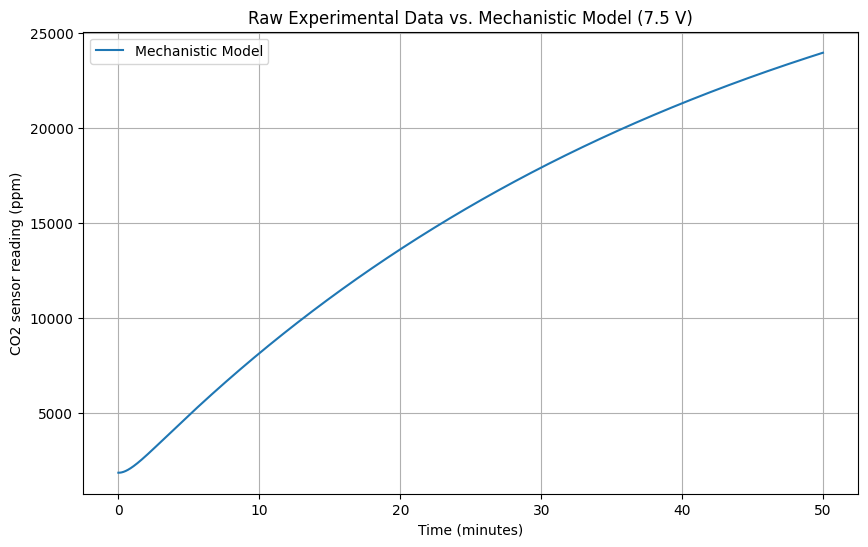

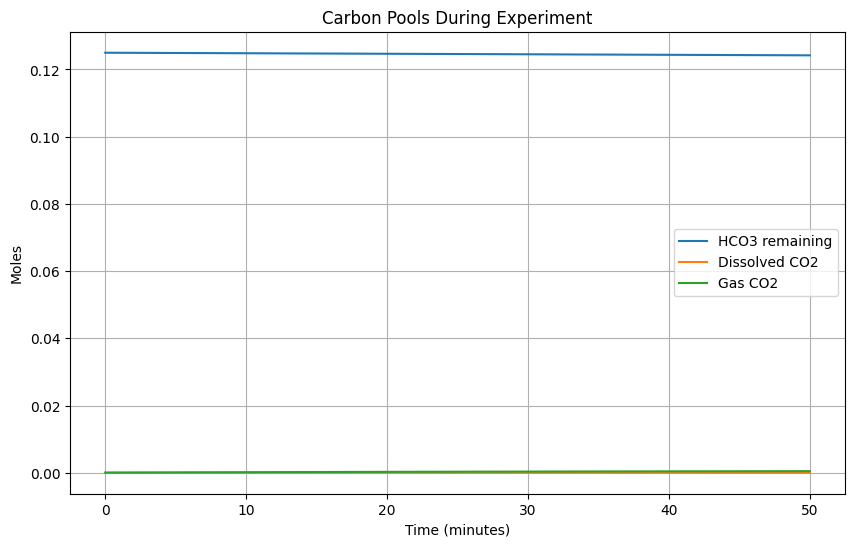

Final ppm: 23943.415565333577
Final bicarbonate remaining: 0.12420805702666093 mol
Final energy used: 0.0003123958333333267 kWh
Initial ppm: 1858.0


In [23]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ----------------------------
# 1. Experimental setup
# ----------------------------

minutes = 50
dt = 1  # seconds
steps = int(minutes * 60 / dt)
time_s = np.arange(steps) * dt
time_min = time_s / 60

# Water solution
volume_water_L = 5
baking_soda_g_per_L = 2.1
salt_g_per_L = 35

M_NaHCO3 = 84.01  # g/mol
HCO3_initial = baking_soda_g_per_L * volume_water_L / M_NaHCO3

# Gas headspace inside/above PVC sensor area
V_headspace_L = 0.475   # CHANGE THIS: liters of trapped air near sensor
V_headspace_m3 = V_headspace_L / 1000

# Air conditions
P = 101325  # Pa
T = 298     # K
R = 8.314   # J/mol/K

n_air = P * V_headspace_m3 / (R * T)

# Initial CO2 in air
initial_ppm = 1858
CO2_gas_initial = initial_ppm / 1_000_000 * n_air

# ----------------------------
# 2. Electrochemistry settings
# ----------------------------

F = 96485  # C/mol e-

current = 0.05  # amps, CHANGE THIS
voltage = 7.5  # volts, CHANGE THIS

# fraction of anode current that creates useful H+
# rest may go to chlorine, side reactions, losses, etc.
useful_anode_fraction = 0.5

H_plus_rate = useful_anode_fraction * current / F  # mol H+ / s

print("Initial bicarbonate:", HCO3_initial, "mol")
print("Useful H+ production:", H_plus_rate, "mol/s")
print("Max possible CO2 from bicarbonate:", HCO3_initial * 44.01, "g CO2")

# ----------------------------
# 3. Transfer / leakage settings
# ----------------------------

# Fraction per second of produced dissolved CO2 that enters gas phase
# If bubbling directly into PVC, this could be high.
k_gas_transfer = 0.02  # 1/s, fit this to your data

# Leakage / mixing of headspace air with room air
k_leak = 0.0004  # 1/s, fit this to your data

room_ppm = 420
room_CO2_gas = room_ppm / 1_000_000 * n_air

# ----------------------------
# 4. Arrays
# ----------------------------

HCO3 = np.zeros(steps)
CO2_dissolved = np.zeros(steps)
CO2_gas = np.zeros(steps)
ppm = np.zeros(steps)
energy_kWh = np.zeros(steps)

HCO3[0] = HCO3_initial
CO2_gas[0] = CO2_gas_initial
ppm[0] = initial_ppm

# ----------------------------
# 5. Simulation loop
# ----------------------------

for i in range(1, steps):
    HCO3_prev = HCO3[i-1]
    CO2_d_prev = CO2_dissolved[i-1]
    CO2_g_prev = CO2_gas[i-1]
    E_prev = energy_kWh[i-1]

    # Acid production from anode
    H_added = H_plus_rate * dt

    # Convert bicarbonate to dissolved CO2
    CO2_made = min(H_added, HCO3_prev)

    HCO3_now = HCO3_prev - CO2_made
    CO2_d_now = CO2_d_prev + CO2_made

    # Transfer dissolved CO2 into headspace
    CO2_to_gas = k_gas_transfer * CO2_d_now * dt
    CO2_to_gas = min(CO2_to_gas, CO2_d_now)

    CO2_d_now -= CO2_to_gas
    CO2_g_now = CO2_g_prev + CO2_to_gas

    # Leakage / mixing back toward room CO2
    leak_loss = k_leak * (CO2_g_now - room_CO2_gas) * dt
    CO2_g_now -= leak_loss

    # Save
    HCO3[i] = HCO3_now
    CO2_dissolved[i] = CO2_d_now
    CO2_gas[i] = CO2_g_now
    ppm[i] = 1_000_000 * CO2_g_now / n_air

    # Energy
    power_W = current * voltage
    energy_kWh[i] = E_prev + power_W * dt / 3_600_000

# ----------------------------
# 6. Plot simulated sensor curve
# ----------------------------

df = pd.read_csv("cc.csv")

plt.figure(figsize=(10, 6))
plt.plot(time_min, ppm, label="Mechanistic Model")
# plt.plot(np.array(df["Time"]) / 60, df["CO2 (ppm)"], label="Raw Data")
plt.xlabel("Time (minutes)")
plt.ylabel("CO2 sensor reading (ppm)")
plt.title("Raw Experimental Data vs. Mechanistic Model (7.5 V)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(time_min, HCO3, label="HCO3 remaining")
plt.plot(time_min, CO2_dissolved, label="Dissolved CO2")
plt.plot(time_min, CO2_gas, label="Gas CO2")
plt.xlabel("Time (minutes)")
plt.ylabel("Moles")
plt.title("Carbon Pools During Experiment")
plt.legend()
plt.grid(True)
plt.show()

print("Final ppm:", ppm[-1])
print("Final bicarbonate remaining:", HCO3[-1], "mol")
print("Final energy used:", energy_kWh[-1], "kWh")

print("Initial ppm:", ppm[0])